In [1]:
import torch
import torch.nn as nn
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import clear_output, Video, display, HTML

# Import visualization utilities
from visualization_utils import (
    preprocess_frame,
    FrameStack,
    visualize_game_frame,
    play_and_visualize_game,
    check_existing_videos,
    display_video_grid,
    extract_episode_or_step_number
)

In [2]:
import ale_py
gym.register_envs(ale_py)

# VISUALIZATION CONFIGURATION PARAMETERS
VISUALIZATION_FRAME_SKIP = 10  # Show every Nth step (10 = show every 10th step)
# VISUALIZATION_FRAME_SKIP = 5   # More frequent visualization
# VISUALIZATION_FRAME_SKIP = 20  # Less frequent visualization
# VISUALIZATION_FRAME_SKIP = 1   # Show every single step (warning: very slow!)

In [3]:
class ConvDQN_CNN1(nn.Module):
    """V1 CNN architecture (32->64->64 filters)"""
    def __init__(self, input_channels, action_size):
        super(ConvDQN_CNN1, self).__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=8, stride=4, padding=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU()
        )
        
        self.feature_size = self._get_conv_output_size()
        
        self.fc = nn.Sequential(
            nn.Linear(self.feature_size, 512),
            nn.ReLU(),
            nn.Linear(512, action_size)
        )
    
    def _get_conv_output_size(self):
        with torch.no_grad():
            dummy_input = torch.zeros(1, 2, 84, 84)
            conv_output = self.conv(dummy_input)
            return conv_output.numel() // conv_output.size(0)
    
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [4]:
def find_v1_run_checkpoints():
    """Find checkpoints from the latest pong_dqn_cnn_v1 training run"""
    # Point to the latest run directory with pong_dqn_cnn_enhanced checkpoints
    v1_run_dir = Path.home() / "dev" / "rl_study" / "artifacts" / "run_aefead089780402ebeb5d243ce4b0963"
    
    if not v1_run_dir.exists():
        print(f"V1 run directory not found: {v1_run_dir}")
        return []
    
    print(f"Using latest v1 run: {v1_run_dir.name}")
    
    # Look for pong_dqn_cnn_enhanced checkpoints (latest v1 training)
    checkpoint_files = list(v1_run_dir.glob("pong_dqn_cnn_enhanced_checkpoint*.pth"))
    
    checkpoints = []
    for file_path in checkpoint_files:
        checkpoints.append({
            'path': str(file_path),
            'filename': file_path.name,
            'run_dir': v1_run_dir.name
        })
    
    # Sort by episode/step number
    checkpoints.sort(key=extract_episode_or_step_number)
    
    return checkpoints

def load_model(checkpoint_path):
    """Load v1 model from checkpoint"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Create v1 model
    model = ConvDQN_CNN1(input_channels=2, action_size=6).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    # Extract metadata
    metadata = {
        'episode': checkpoint.get('episode', checkpoint.get('total_steps', 'unknown')),
        'avg_reward': checkpoint.get('avg_reward', 'unknown'),
        'epsilon': checkpoint.get('epsilon', 'unknown'),
        'architecture': 'V1 (32→64→64)',
        'run_id': checkpoint.get('run_id', 'unknown'),
        'total_steps': checkpoint.get('total_steps', 'unknown')
    }
    
    return model, metadata, device

In [5]:
# Find and display available v1 checkpoints
checkpoints = find_v1_run_checkpoints()

if checkpoints:
    print(f"Found {len(checkpoints)} checkpoints from v1 run:")
    for i, cp in enumerate(checkpoints):
        print(f"{i}: {cp['filename']}")
else:
    print("No checkpoints found. Run v1 training first!")

Using latest v1 run: run_aefead089780402ebeb5d243ce4b0963
Found 4 checkpoints from v1 run:
0: pong_dqn_cnn_enhanced_checkpoint_ep0.pth
1: pong_dqn_cnn_enhanced_checkpoint_ep10000.pth
2: pong_dqn_cnn_enhanced_checkpoint_ep20000.pth
3: pong_dqn_cnn_enhanced_checkpoint_ep30000.pth


In [6]:
# Check for existing videos and display them
if checkpoints:
    existing_videos = check_existing_videos(checkpoints)
    
    if existing_videos:
        print(f"\n{'='*80}")
        print(f"FOUND {len(existing_videos)} EXISTING GAMEPLAY VIDEOS")
        print(f"{'='*80}")
        
        for checkpoint_name, video_info in existing_videos.items():
            print(f"✓ {checkpoint_name}: {video_info['size_mb']:.2f} MB")
            print(f"  Path: {video_info['path']}")
        
        print(f"\n{'='*80}")
        print("DISPLAYING EXISTING VIDEOS")
        print(f"{'='*80}\n")
        
        # Display all existing videos
        video_paths = [str(v['path']) for v in existing_videos.values()]
        titles = [name.replace('_checkpoint', '').replace('.pth', '') for name in existing_videos.keys()]
        display_video_grid(video_paths, titles)
        
    else:
        print(f"\nNo existing videos found. Videos will be generated in the next cell.")
else:
    print("No checkpoints available.")


No existing videos found. Videos will be generated in the next cell.


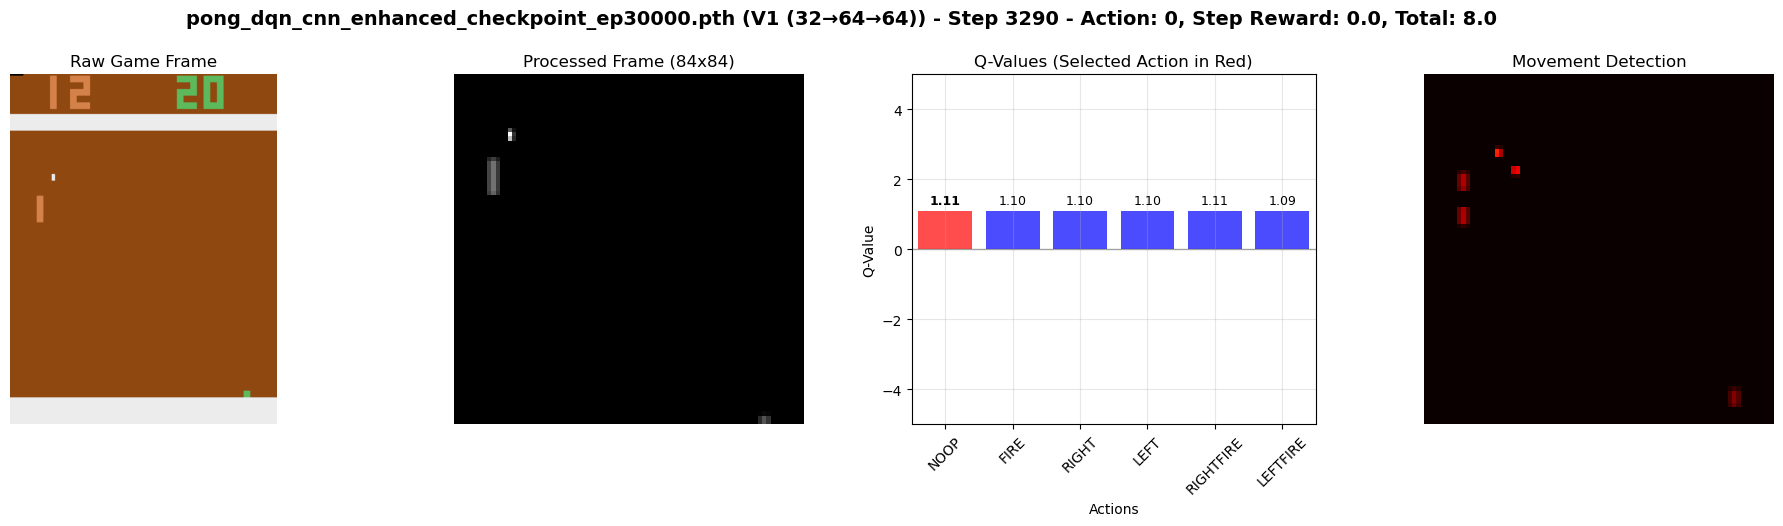

Step 3290: Action=0, Reward=0.0, Total=8.0
Video saved to: /home/bmartins/dev/rl_study/artifacts/run_aefead089780402ebeb5d243ce4b0963/pong_dqn_cnn_enhanced_checkpoint_ep30000_gameplay.mp4

Game finished!
Final reward: 9.0
Game length: 3294 steps
Frames visualized: 330

COMPREHENSIVE ANALYSIS SUMMARY - V1 RUN

Checkpoints with new gameplay (4):
Checkpoint                               Architecture         Train Ep   Train Avg  Game Reward  Game Length 
----------------------------------------------------------------------------------------------------
pong_dqn_cnn_enhanced_checkpoint_ep0.pth V1 (32→64→64)        0          -20.0      -21.0        824         
pong_dqn_cnn_enhanced_checkpoint_ep10000.pth V1 (32→64→64)        10000      -12.1      -21.0        4237        
pong_dqn_cnn_enhanced_checkpoint_ep20000.pth V1 (32→64→64)        20000      9.7        -19.0        1738        
pong_dqn_cnn_enhanced_checkpoint_ep30000.pth V1 (32→64→64)        30000      12.4       9.0          3294

In [7]:
# Video saving configuration
SAVE_VIDEOS = True  # Set to True to save gameplay videos
FORCE_REGENERATE = False  # Set to True to regenerate videos even if they exist

# Select which checkpoint to analyze
if checkpoints:
    print("Available checkpoints (sorted by episode/step number):")
    for i, checkpoint in enumerate(checkpoints):
        print(f"{i}: {checkpoint['filename']}")
    
    # Select checkpoints to analyze
    if len(checkpoints) > 10:
        selected_indices = list(range(0, len(checkpoints), max(1, len(checkpoints) // 10)))
        print(f"\nAnalyzing {len(selected_indices)} checkpoints (evenly distributed): {selected_indices}")
    else:
        selected_indices = list(range(len(checkpoints)))
        print(f"\nAnalyzing all {len(selected_indices)} checkpoints: {selected_indices}")
    
    print("=" * 80)
    
    results = []
    artifacts_dir = Path(checkpoints[0]['path']).parent
    existing_videos = check_existing_videos(checkpoints)
    
    for idx in selected_indices:
        checkpoint = checkpoints[idx]
        print(f"\n{'='*80}")
        print(f"ANALYZING CHECKPOINT {idx}: {checkpoint['filename']}")
        print(f"{'='*80}")
        
        try:
            model, metadata, device = load_model(checkpoint['path'])
            
            print(f"Architecture: {metadata['architecture']}")
            print(f"Training Episode: {metadata['episode']}")
            print(f"Training Avg Reward: {metadata['avg_reward']}")
            print(f"Training Epsilon: {metadata['epsilon']}")
            if metadata['total_steps'] != 'unknown':
                print(f"Total Training Steps: {metadata['total_steps']}")
            if metadata['run_id'] != 'unknown':
                print(f"Run ID: {metadata['run_id']}")
            print()
            
            video_path = None
            should_save_video = False
            
            if SAVE_VIDEOS:
                video_filename = checkpoint['filename'].replace('.pth', '_gameplay.mp4')
                video_path = artifacts_dir / video_filename
                
                if checkpoint['filename'] in existing_videos and not FORCE_REGENERATE:
                    print(f"✓ Video already exists: {video_path}")
                    print(f"  Skipping gameplay generation. Set FORCE_REGENERATE=True to regenerate.")
                    
                    result = {
                        'checkpoint': checkpoint['filename'],
                        'architecture': metadata['architecture'],
                        'training_episode': metadata['episode'],
                        'training_avg_reward': metadata['avg_reward'],
                        'training_epsilon': metadata['epsilon'],
                        'video_size_mb': existing_videos[checkpoint['filename']]['size_mb'],
                        'total_steps': metadata['total_steps'],
                        'video_path': str(video_path),
                        'video_status': 'existing'
                    }
                    results.append(result)
                    continue
                else:
                    should_save_video = True
                    if FORCE_REGENERATE and checkpoint['filename'] in existing_videos:
                        print(f"⚠ Regenerating existing video: {video_path}")
            
            # Play game with VISUALIZATION_FRAME_SKIP parameter
            final_reward, game_length = play_and_visualize_game(
                model, device, checkpoint['filename'], metadata['architecture'],
                visualization_frame_skip=VISUALIZATION_FRAME_SKIP,
                save_video=should_save_video, video_path=video_path
            )
            
            result = {
                'checkpoint': checkpoint['filename'],
                'architecture': metadata['architecture'],
                'training_episode': metadata['episode'],
                'training_avg_reward': metadata['avg_reward'],
                'training_epsilon': metadata['epsilon'],
                'game_reward': final_reward,
                'game_length': game_length,
                'total_steps': metadata['total_steps'],
                'video_status': 'new'
            }
            if SAVE_VIDEOS:
                result['video_path'] = str(video_path)
            results.append(result)
            
        except Exception as e:
            print(f"Error with checkpoint {checkpoint['filename']}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    # Summary of results
    if results:
        print(f"\n{'='*100}")
        print("COMPREHENSIVE ANALYSIS SUMMARY - V1 RUN")
        print(f"{'='*100}")
        
        new_results = [r for r in results if r.get('video_status') == 'new']
        existing_results = [r for r in results if r.get('video_status') == 'existing']
        
        if existing_results:
            print(f"\nCheckpoints with existing videos ({len(existing_results)}):")
            print(f"{'Checkpoint':<40} {'Architecture':<20} {'Train Ep':<10} {'Video Size (MB)':<15}")
            print("-" * 100)
            for result in existing_results:
                print(f"{result['checkpoint']:<40} {result['architecture']:<20} {str(result['training_episode']):<10} "
                      f"{result['video_size_mb']:<15.2f}")
        
        if new_results:
            print(f"\nCheckpoints with new gameplay ({len(new_results)}):")
            print(f"{'Checkpoint':<40} {'Architecture':<20} {'Train Ep':<10} {'Train Avg':<10} {'Game Reward':<12} {'Game Length':<12}")
            print("-" * 100)
            
            for result in new_results:
                print(f"{result['checkpoint']:<40} {result['architecture']:<20} {str(result['training_episode']):<10} "
                      f"{str(result['training_avg_reward']):<10} {result['game_reward']:<12.1f} {result['game_length']:<12}")
            
            if new_results:
                avg_game_reward = sum(r['game_reward'] for r in new_results) / len(new_results)
                avg_game_length = sum(r['game_length'] for r in new_results) / len(new_results)
                
                print("-" * 100)
                print(f"{'AVERAGES':<40} {'':<20} {'':<10} {'':<10} {avg_game_reward:<12.1f} {avg_game_length:<12.1f}")
        
        print()
        
        if SAVE_VIDEOS:
            print(f"Videos location: {artifacts_dir}")
            if new_results:
                print(f"  New videos generated: {len(new_results)}")
            if existing_results:
                print(f"  Existing videos reused: {len(existing_results)}")
            
else:
    print("No checkpoints available to analyze!")
    print("Make sure to run v1 training first with pong_dqn_cnn.ipynb")